Question 5

In the notebook I am only showing the code used to find the normal distribution values and have shown the rest of the working in the pdf.

In [6]:
from math import erf, sqrt

def Phi(z):
    return 0.5 * (1 + erf(z / sqrt(2)))

z1 = -1.50
z2 = -2.75

phi_z1 = Phi(z1)
phi_z2 = Phi(z2)

probability = phi_z1 - phi_z2

# Print results
print(f"Phi({z1}) = {phi_z1:.6f}")
print(f"Phi({z2}) = {phi_z2:.6f}")
print(f"P({z2} < Z < {z1}) = {probability:.6f}")


Phi(-1.5) = 0.066807
Phi(-2.75) = 0.002980
P(-2.75 < Z < -1.5) = 0.063827


Question 7

The following is the calculation for mean, variance and std. deviation for Formulation 1 and plloting of the Box Plots required by the question

Formulation 1:
Mean = 2.415
Variance = 0.28537142857142855
Standard Deviation = 0.534201674062735


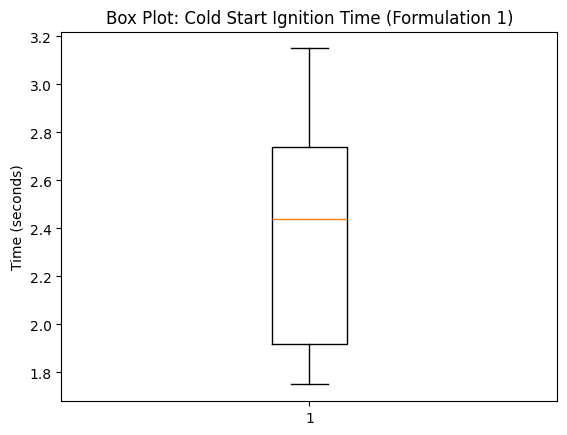

C:\Users\cavlc\AppData\Local\Temp\ipykernel_18664\264116270.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([formulation1, formulation2],


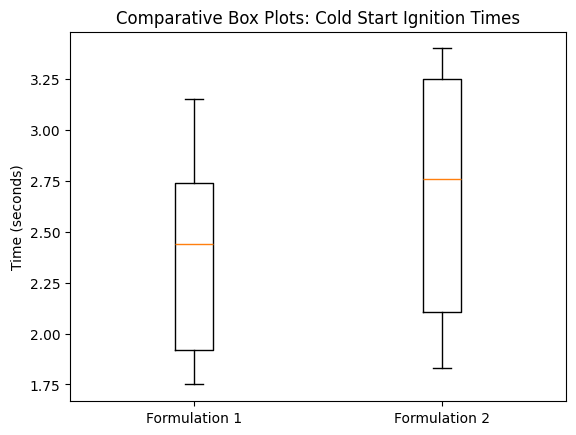

In [7]:
import numpy as np
import matplotlib.pyplot as plt

formulation1 = np.array([1.75, 1.92, 2.62, 2.35, 3.09, 3.15, 2.53, 1.91])
formulation2 = np.array([1.83, 1.99, 3.13, 3.29, 2.65, 2.87, 3.40, 2.46, 1.89, 3.35])

mean1 = np.mean(formulation1)
var1 = np.var(formulation1, ddof=1)   
std1 = np.std(formulation1, ddof=1)  

print("Formulation 1:")
print("Mean =", mean1)
print("Variance =", var1)
print("Standard Deviation =", std1)

# Box plot for formulation 1
plt.figure()
plt.boxplot(formulation1)
plt.ylabel("Time (seconds)")
plt.title("Box Plot: Cold Start Ignition Time (Formulation 1)")
plt.show()

# Comparative box plots
plt.figure()
plt.boxplot([formulation1, formulation2],
            labels=["Formulation 1", "Formulation 2"])
plt.ylabel("Time (seconds)")
plt.title("Comparative Box Plots: Cold Start Ignition Times")
plt.show()


Question 8

In the pdf I have explained the working and formulas used, here I have shown the code used to complete the table I have uploaded in the pdf

In [8]:
import pandas as pd

data = {
    "Name": ["P. Lee", "R. Jones", "J. Smith", "A. Patel", "M. Owen",
             "S. Green", "N. Cook", "W. Hands", "P. Rice", "F. Marsh"],
    "Weight (kg)": [50, 115, 96, 41, 79, 109, 73, 104, 64, 136],
    "Height (m)": [1.52, 1.77, 1.83, 1.55, 1.82, 1.89, 1.76, 1.71, 1.74, 1.78],
    "Diabetes": [0, 1, 0, 0, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

# (a) Min-max normalization
w_min = df["Weight (kg)"].min()
w_max = df["Weight (kg)"].max()
df["Weight_norm"] = (df["Weight (kg)"] - w_min) / (w_max - w_min)

# (b) Binning
def bin_weight(w):
    if w < 60:
        return "Low"
    elif w <= 100:
        return "Medium"
    else:
        return "High"

df["Weight_bin"] = df["Weight (kg)"].apply(bin_weight)

# (c) BMI
df["BMI"] = df["Weight (kg)"] / (df["Height (m)"]**2)

df


,Name,Weight (kg),Height (m),Diabetes,Weight_norm,Weight_bin,BMI
0,P. Lee,50,1.52,0,0.094737,Low,21.641274
1,R. Jones,115,1.77,1,0.778947,High,36.707204
2,J. Smith,96,1.83,0,0.578947,Medium,28.666129
3,A. Patel,41,1.55,0,0.000000,Low,17.065557
4,M. Owen,79,1.82,0,0.400000,Medium,23.849777
5,S. Green,109,1.89,1,0.715789,High,30.514263
6,N. Cook,73,1.76,0,0.336842,Medium,23.566632
7,W. Hands,104,1.71,1,0.663158,High,35.566499
8,P. Rice,64,1.74,0,0.242105,Medium,21.138856
9,F. Marsh,136,1.78,1,1.000000,High,42.923873


Question 9

First I have created the dataset for this question given in Table 2 of the Assignment as a Data Frame

In [38]:
data = {
    "Customer": ["B. March","B. March","B. March","J. Bain","T. Goss","T. Goss",
                 "L. Nye","L. Nye","S. Cann","E. Sims","P. Judd","P. Judd",
                 "G. Hinton","G. Hinton","G. Hinton","G. Hinton","H. Fu","H. Taylor"],
    "Store": ["New York, NY","New York, NY","New York, NY","New York, NY",
              "Washington, DC","Washington, DC","New York, NY","New York, NY",
              "Washington, DC","Washington, DC","New York, NY","New York, NY",
              "Washington, DC","Washington, DC","Washington, DC","Washington, DC",
              "New York, NY","New York, NY"],
    "Product Category": ["Laptop","Printer","Scanner","Scanner","Printer","Scanner",
                         "Desktop","Printer","Desktop","Laptop","Desktop","Scanner",
                         "Laptop","Desktop","Printer","Scanner","Desktop","Scanner"],
    "Sale Price": [950,350,400,500,200,550,600,300,600,700,700,200,700,600,350,500,450,400],
    "Profit": [190,105,100,125,60,140,60,90,60,140,70,50,140,60,105,125,45,100]
}

df = pd.DataFrame(data)

The following code blocks show the code snippets and outputs as required by each part of Q9

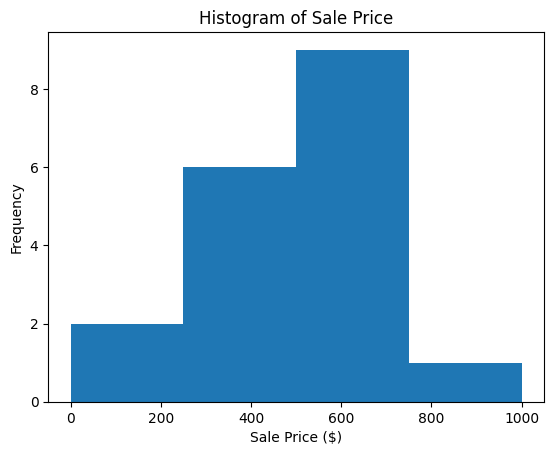

In [ ]:
# (a) Histogram of Sale Price
bins = [0, 250, 500, 750, 1000]
plt.figure()
plt.hist(df["Sale Price"], bins=bins)
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.title("Histogram of Sale Price")
plt.show()


In [11]:
# (b) Contingency table
contingency_table = pd.crosstab(df["Store"], df["Product Category"])
print("\nContingency Table (Store x Product Category):\n")
print(contingency_table)



Contingency Table (Store x Product Category):

Product Category  Desktop  Laptop  Printer  Scanner
Store                                              
New York, NY            3       1        2        4
Washington, DC          2       2        2        2


In [41]:
# (c-i) Group by Customer
customer_summary = df.groupby("Customer").agg(
    Count=("Sale Price", "count"),
    Total_Sales=("Sale Price", "sum")
)
print("\nc-i) Grouped by Customer:")
print(customer_summary)

# (c-ii) Group by Store
store_summary = df.groupby("Store").agg(
    Count=("Sale Price", "count"),
    Mean_Sale_Price=("Sale Price", "mean")
)
print("\nc-ii) Grouped by Store:")
print(store_summary)

# (c-iii) Group by Product Category
product_summary = df.groupby("Product Category").agg(
    Count=("Profit", "count"),
    Total_Profit=("Profit", "sum")
)
print("\nc-iii) Grouped by Product Category:\n")
print(product_summary)



c-i) Grouped by Customer:
           Count  Total_Sales
Customer                     
B. March       3         1700
E. Sims        1          700
G. Hinton      4         2150
H. Fu          1          450
H. Taylor      1          400
J. Bain        1          500
L. Nye         2          900
P. Judd        2          900
S. Cann        1          600
T. Goss        2          750

c-ii) Grouped by Store:
                Count  Mean_Sale_Price
Store                                 
New York, NY       10            485.0
Washington, DC      8            525.0

c-iii) Grouped by Product Category:

                  Count  Total_Profit
Product Category                     
Desktop               5           295
Laptop                3           470
Printer               4           360
Scanner               6           640


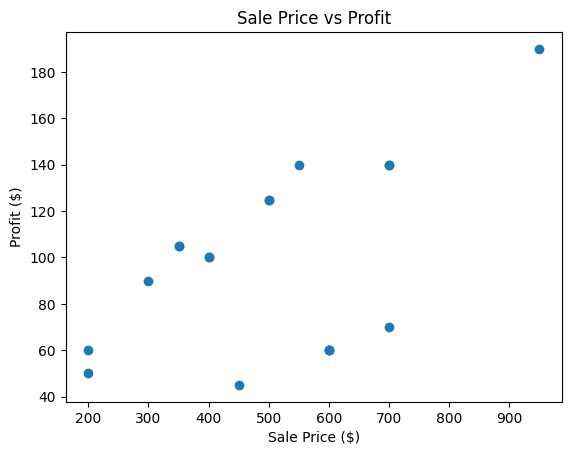

In [ ]:
# (d) Scatterplot: Sale Price vs Profit 
plt.figure()
plt.scatter(df["Sale Price"], df["Profit"])
plt.xlabel("Sale Price ($)")
plt.ylabel("Profit ($)")
plt.title("Sale Price vs Profit")
plt.show()


Question 10

In [15]:
import seaborn as sns

df = pd.read_csv("A1.csv")

print(df.head())

   Sample Number Classes  Feature 1  Feature 2  Feature 3  Feature 4     Sex
0              1       A       39.2       18.6        190       4250    MALE
1              2       B       45.2       13.8        215       4750  FEMALE
2              3       C       51.9       19.5        206       3950    MALE
3              4       A       42.8       18.5        195       4250    MALE
4              5       B       42.6       13.7        213       4950  FEMALE


In [17]:
# (a) Frequency of samples for each class

class_frequency = df['Classes'].value_counts()
print("Class Frequency:\n", class_frequency)

Class Frequency:
 Classes
A    151
B    123
C     68
Name: count, dtype: int64


In [24]:
# (b) Data description and IQR

features = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4']

description = df[features].describe()
print("\nData Description:\n", description)

Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1
print("\nInterquartile Range (IQR):\n", IQR)


Data Description:
         Feature 1   Feature 2   Feature 3    Feature 4
count  342.000000  342.000000  342.000000   342.000000
mean    43.921930   17.151170  200.915205  4201.754386
std      5.459584    1.974793   14.061714   801.954536
min     32.100000   13.100000  172.000000  2700.000000
25%     39.225000   15.600000  190.000000  3550.000000
50%     44.450000   17.300000  197.000000  4050.000000
75%     48.500000   18.700000  213.000000  4750.000000
max     59.600000   21.500000  231.000000  6300.000000

Interquartile Range (IQR):
 Feature 1       9.275
Feature 2       3.100
Feature 3      23.000
Feature 4    1200.000
dtype: float64


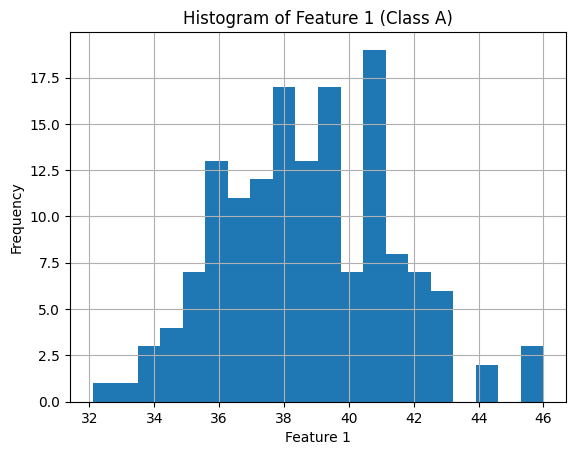

In [27]:
# (c) Histogram of feature 1 for class A

plt.figure()
df[df['Classes'] == 'A']['Feature 1'].hist(bins=20)
plt.xlabel("Feature 1")
plt.ylabel("Frequency")
plt.title("Histogram of Feature 1 (Class A)")
plt.show()

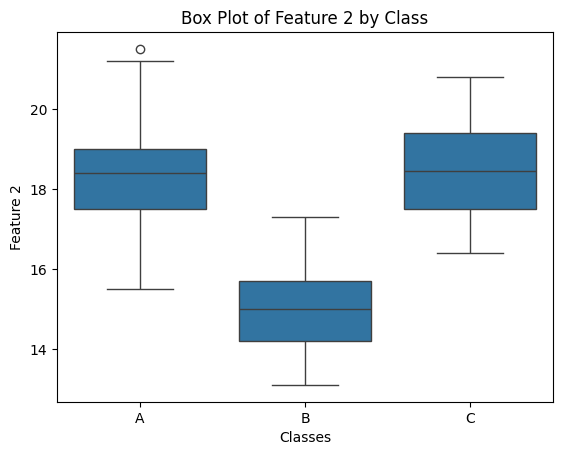

In [28]:
# (d) Box plot of Feature 2 for each class

plt.figure()
sns.boxplot(x='Classes', y='Feature 2', data=df)
plt.title("Box Plot of Feature 2 by Class")
plt.show()


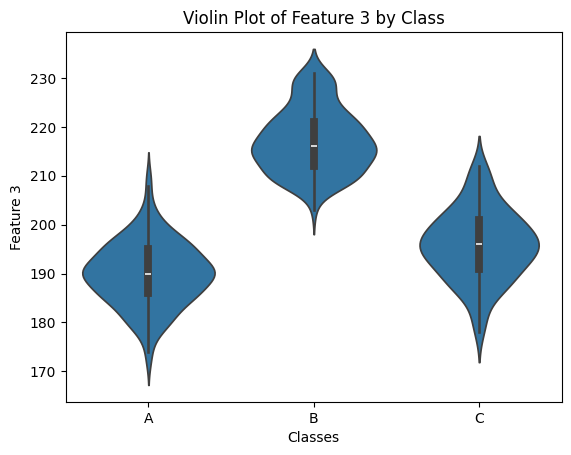

In [30]:
# (e) Violin plot of Feature 3 for each class

plt.figure()
sns.violinplot(x='Classes', y='Feature 3', data=df)
plt.title("Violin Plot of Feature 3 by Class")
plt.show()


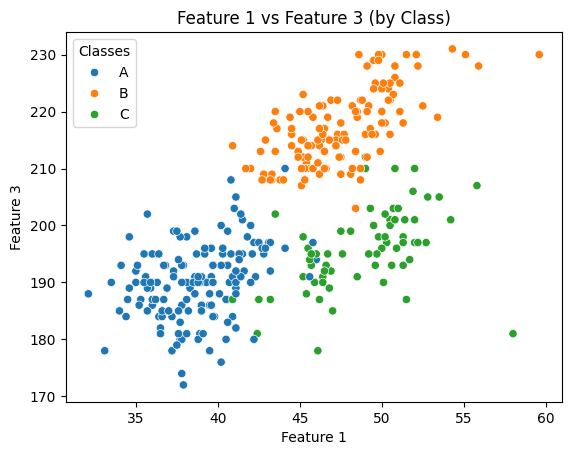

In [31]:
# (f) Scatter plot: Feature 1 vs Feature 3

plt.figure()
sns.scatterplot(x='Feature 1', y='Feature 3', hue='Classes', data=df)
plt.title("Feature 1 vs Feature 3 (by Class)")
plt.show()


C:\Users\cavlc\AppData\Local\Temp\ipykernel_18664\2053339776.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


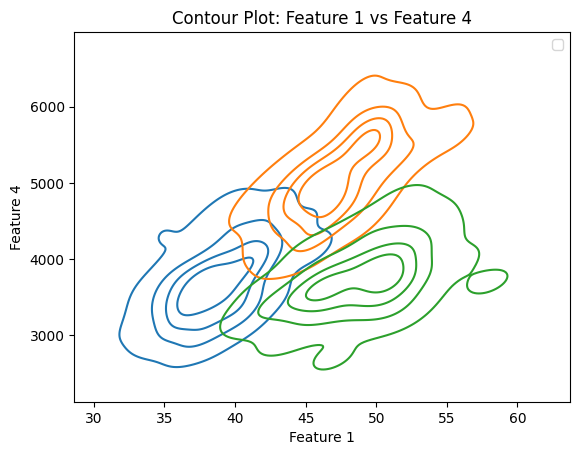

In [32]:
# (g) Contour plot: Feature 1 vs Feature 4 (by class)

plt.figure()
for cls in df['Classes'].unique():
    subset = df[df['Classes'] == cls]
    sns.kdeplot(
        x=subset['Feature 1'],
        y=subset['Feature 4'],
        levels=5,
        label=f"Class {cls}"
    )

plt.title("Contour Plot: Feature 1 vs Feature 4")
plt.xlabel("Feature 1")
plt.ylabel("Feature 4")
plt.legend()
plt.show()

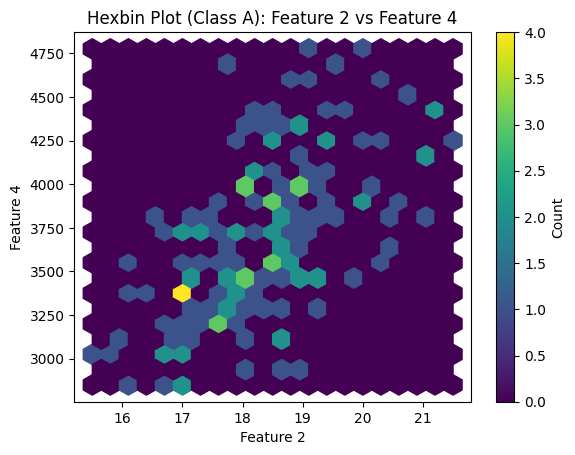

In [33]:
# (h) Hexbin plot for Class A: Feature 2 vs Feature 4

plt.figure()
subset_A = df[df['Classes'] == 'A']
plt.hexbin(subset_A['Feature 2'], subset_A['Feature 4'], gridsize=20)
plt.colorbar(label='Count')
plt.title("Hexbin Plot (Class A): Feature 2 vs Feature 4")
plt.xlabel("Feature 2")
plt.ylabel("Feature 4")
plt.show()



Correlation Matrix:
           Feature 1  Feature 2  Feature 3  Feature 4
Feature 1   1.000000  -0.235053   0.656181   0.595110
Feature 2  -0.235053   1.000000  -0.583851  -0.471916
Feature 3   0.656181  -0.583851   1.000000   0.871202
Feature 4   0.595110  -0.471916   0.871202   1.000000


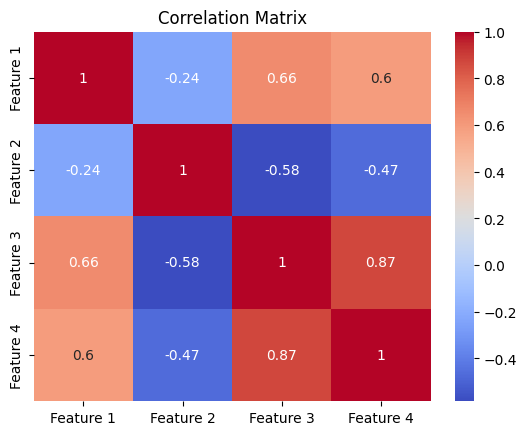

In [34]:
# (i) Correlation matrix

corr = df[features].corr()
print("\nCorrelation Matrix:")
print(corr)

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


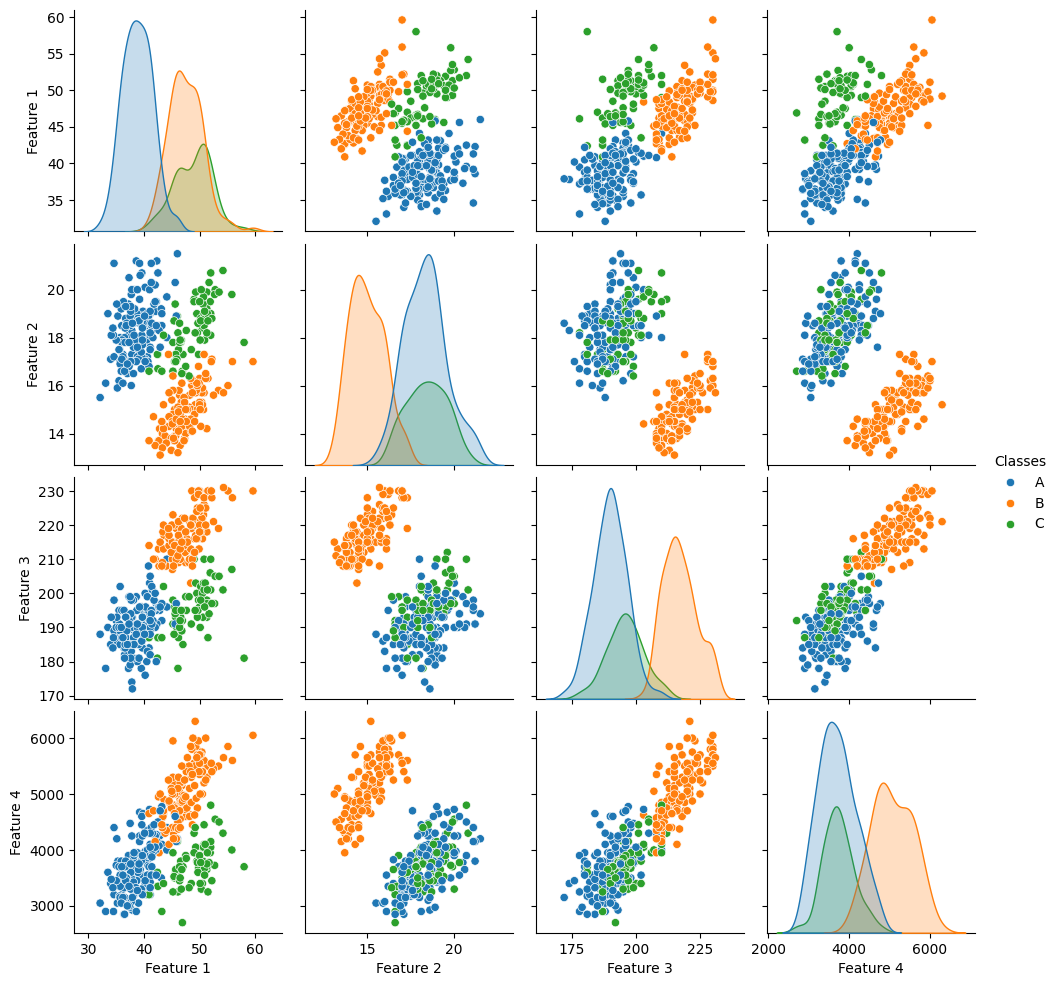

In [35]:
# (j) Pair plot for all features

sns.pairplot(df, vars=features, hue='Classes')
plt.show()